# Manta Rays Modeling Sprint 1
- Eren Onat, Victoria Johnson, Will Graham

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Part A
### Model between deer and finite food source (Logistic Growth Model)

In [51]:
# we need to model the realtionship between Deer with a finite food source using the logictic growth model. The logistic growth model is given by the equation:
# P(t) = K / (1 + (K - P0) / P0

In [52]:
def logistic_model(t, K, r, x0):
    """
    Standard logistic growth model: x(t) = K / (1 + A*exp(-r*t))
    where A = (K - x0) / x0
    
    Parameters:
    - K: carrying capacity (maximum sustainable population)
    - r: intrinsic growth rate (per unit time)
    - x0: initial population at t=0
    """
    A = (K - x0) / x0
    return K / (1 + A * np.exp(-r * t))

x0 = 10  # Initial population
K = 100  # Carrying capacity
r = 0.1 # Growth rate
t = np.linspace(0, 100, 1000) # Time points

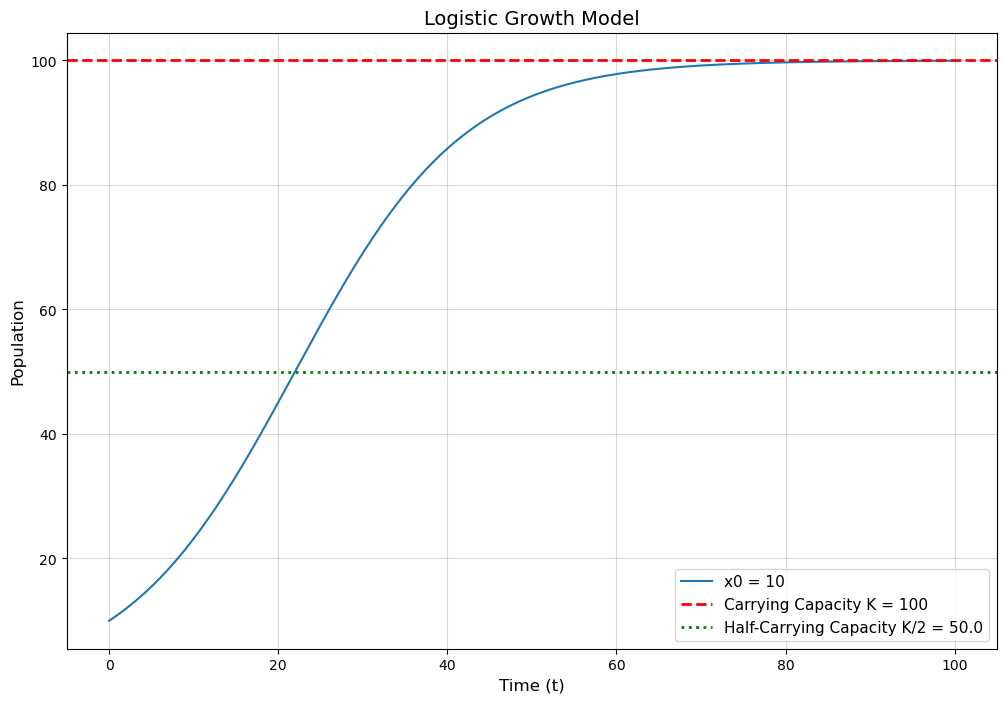

In [53]:
population = logistic_model(t, K, r, x0)
plt.figure(figsize=(12, 8))
plt.plot(t, population, label=f'x0 = {x0}')
plt.axhline(y=K, color='red', linestyle='--', label=f'Carrying Capacity K = {K}', linewidth=2)
plt.axhline(y=K/2, color='green', linestyle=':', label=f'Half-Carrying Capacity K/2 = {K/2}', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.title('Logistic Growth Model', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.5)
plt.show()

# Gemeni Simulations
Part A: gompartz model


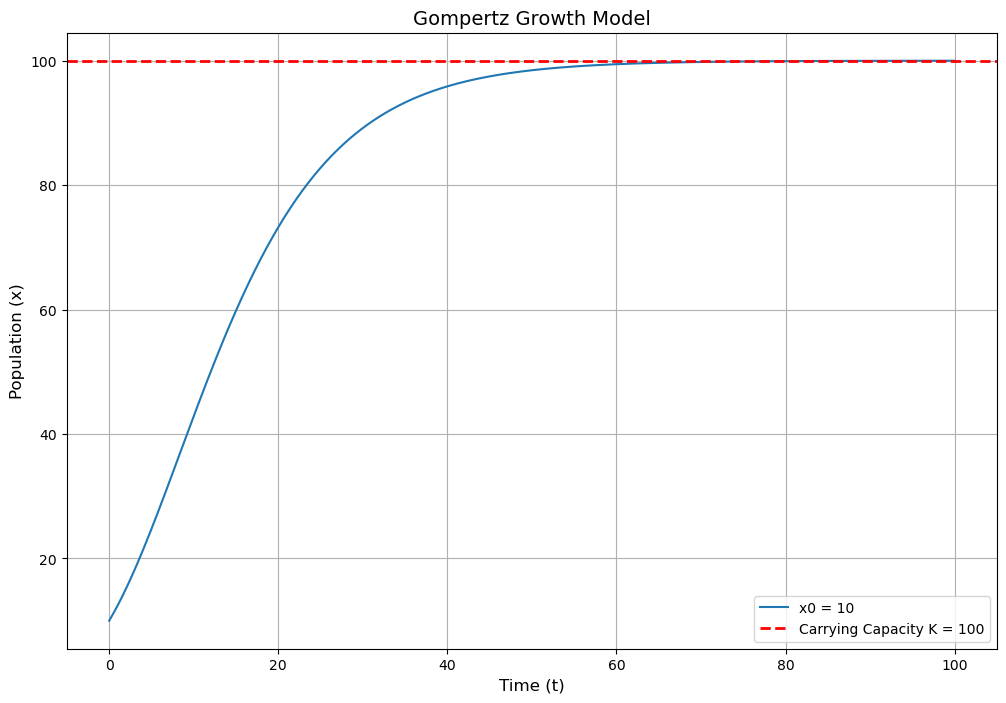

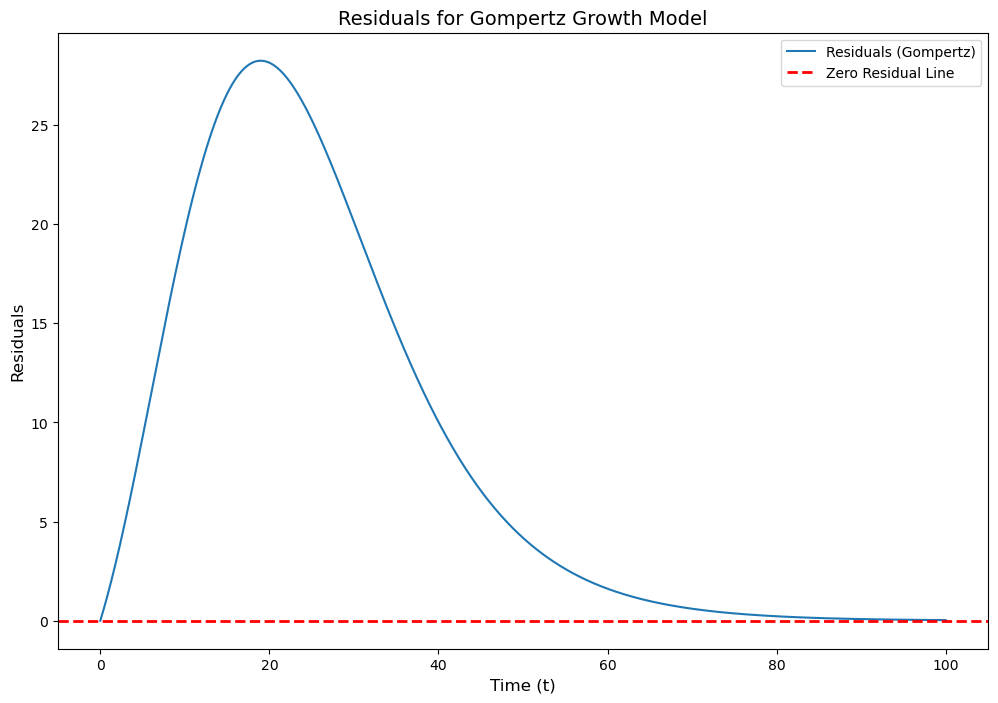

In [54]:
def gompartz_model(t, K, r, x0):
    """
    Gompertz growth model: x(t) = K * exp(-B * exp(-r*t))
    where B = -ln(x0/K)
    
    Parameters:
    - K: carrying capacity (maximum sustainable population)
    - r: intrinsic growth rate (per unit time)
    - x0: initial population at t=0
    """
    B = -np.log(x0 / K)
    return K * np.exp(-B * np.exp(-r * t))

x0 = 10  # Initial population
K = 100  # Carrying capacity
r = 0.1 # Growth rate chosen by gemenai: for visability and ensuring the population reaches carrying capacity within the time frame
t = np.linspace(0, 100, 1000) # Time points

population_gompertz = gompartz_model(t, K, r, x0)
plt.figure(figsize=(12, 8))
plt.plot(t, population_gompertz, label=f'x0 = {x0}')
plt.axhline(y=K, color='red', linestyle='--', label=f'Carrying Capacity K = {K}', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Population (x)', fontsize=12)
plt.title('Gompertz Growth Model', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

#residuals calculation for the gompertz model vs the logistic model
population_logistic = logistic_model(t, K, r, x0)
residuals_gompertz = population_gompertz - population_logistic
plt.figure(figsize=(12, 8))
plt.plot(t, residuals_gompertz, label=f'Residuals (Gompertz)')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals for Gompertz Growth Model', fontsize=14)
plt.legend()
plt.show()

Part B: Theta logictic model

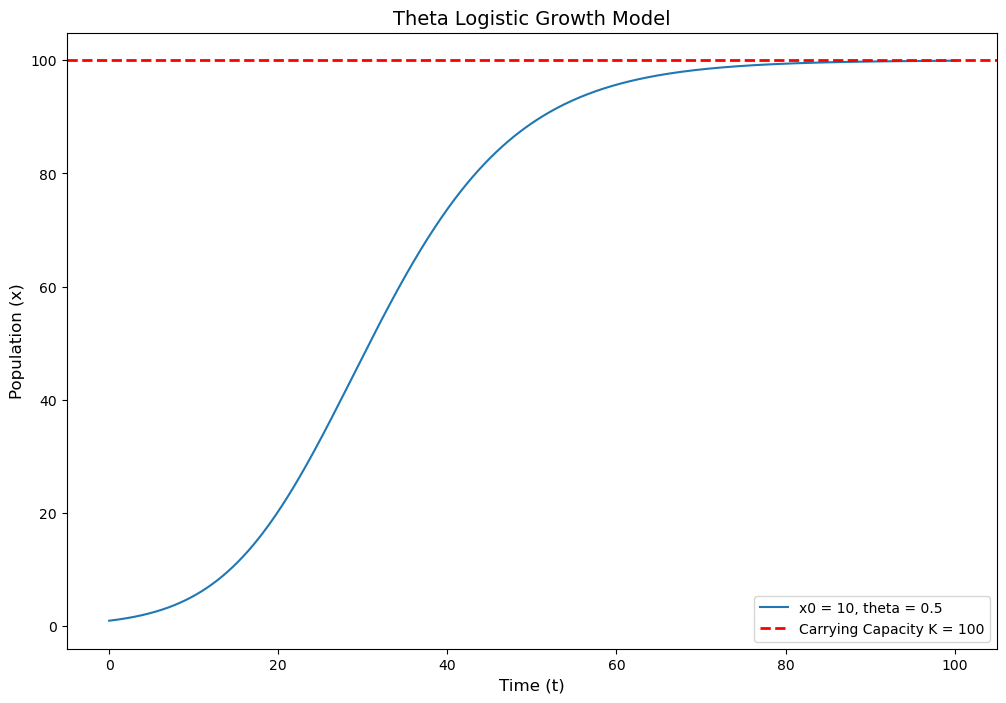

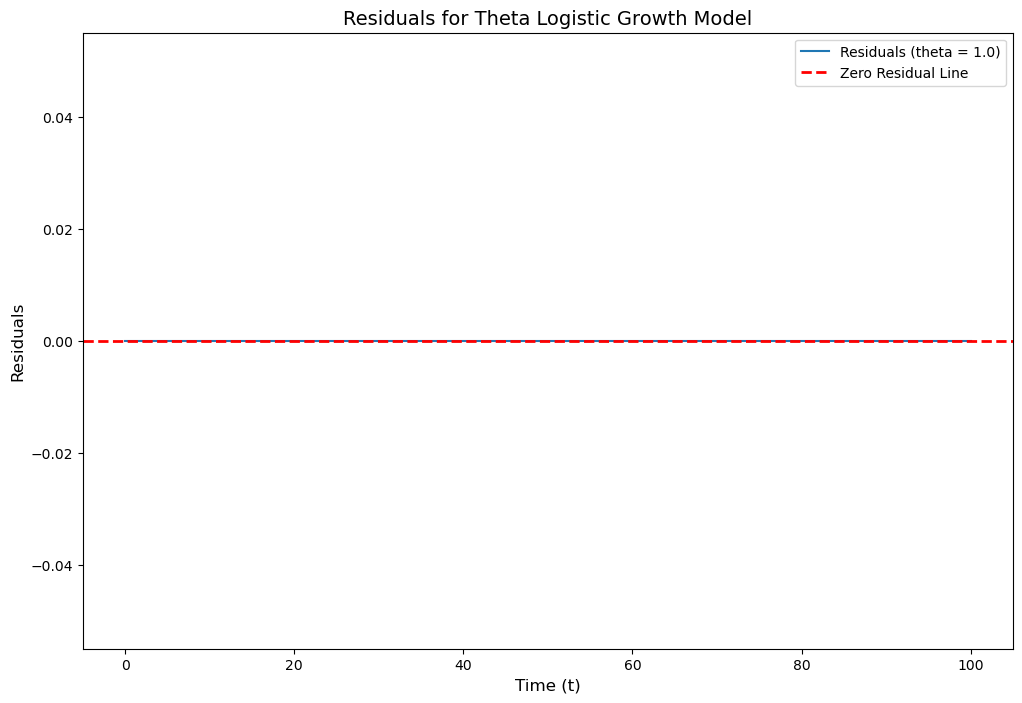

In [55]:
# Theta logistic model: x(t) = K / (1 + A*exp(-r*t))^(1/theta)
def theta_logistic_model(t, K, r, x0, theta):
    """
    Theta logistic growth model: x(t) = K / (1 + A*exp(-r*t))^(1/theta)
    where A = (K - x0) / x0
    
    Parameters:
    - K: carrying capacity (maximum sustainable population)
    - r: intrinsic growth rate (per unit time)
    - x0: initial population at t=0
    - theta: shape parameter that modifies the curvature of the growth
    """
    A = (K - x0) / x0
    return K / (1 + A * np.exp(-r * t))**(1/theta)
x0 = 10  # Initial population
K = 100  # Carrying capacity
r = 0.1 # Growth rate chosen by gemenai: for visability and ensuring the population reaches carrying capacity within the time frame
t = np.linspace(0, 100, 1000) # Time points
theta = 0.5 # Shape parameter, this was chosen by gemenai to show a generalization of the logistic model, where theta < 1 leads to a more gradual approach to carrying capacity, while theta > 1 leads to a more rapid approach.
population_theta_logistic = theta_logistic_model(t, K, r, x0, theta)
plt.figure(figsize=(12, 8))
plt.plot(t, population_theta_logistic, label=f'x0 = {x0}, theta = {theta}')
plt.axhline(y=K, color='red', linestyle='--', label=f'Carrying Capacity K = {K}', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Population (x)', fontsize=12)
plt.title('Theta Logistic Growth Model', fontsize=14)
plt.legend()
plt.show()

#residuals plotted for the theta logistic model vs the logistic model
# we will calculate the residuals for the theta logistic model with theta = 1.0 and plot them against time
theta = 1.0 
population_theta_logistic = theta_logistic_model(t, K, r, x0, theta)
population_logistic = logistic_model(t, K, r, x0)
residuals = population_theta_logistic - population_logistic
plt.figure(figsize=(12, 8))
plt.plot(t, residuals, label=f'Residuals (theta = {theta})')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals for Theta Logistic Growth Model', fontsize=14)
plt.legend()
plt.show()

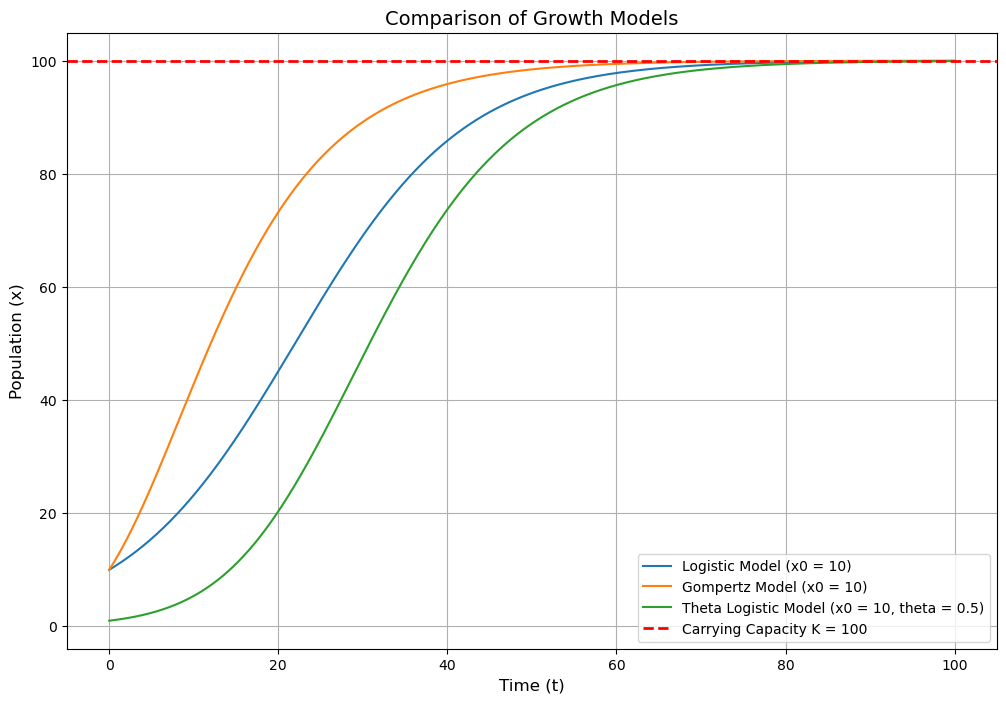

In [56]:

#plot with all 3 models together

x0 = 10  # Initial population
K = 100  # Carrying capacity
r = 0.1  # Growth rate chosen by gemenai: for visability and ensuring the population reaches carrying capacity within the time frame
t = np.linspace(0, 100, 1000)  # Time points
population_logistic = logistic_model(t, K, r, x0)
population_gompertz = gompartz_model(t, K, r, x0)
theta = 0.5 # Shape parameter, this was chosen by gemenai to show a generalization of the logistic model, where theta < 1 leads to a more gradual approach to carrying capacity, while theta > 1 leads to a more rapid approach.
population_theta_logistic = theta_logistic_model(t, K, r, x0, theta)
plt.figure(figsize=(12, 8))
plt.plot(t, population_logistic, label=f'Logistic Model (x0 = {x0})')
plt.plot(t, population_gompertz, label=f'Gompertz Model (x0 = {x0})')
plt.plot(t, population_theta_logistic, label=f'Theta Logistic Model (x0 = {x0}, theta = {theta})')
plt.axhline(y=K, color='red', linestyle='--', label=f'Carrying Capacity K = {K}', linewidth=2)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Population (x)', fontsize=12)
plt.title('Comparison of Growth Models', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [57]:
# compute the time to half carrying capacity for all the models 
half_K = K / 2
time_to_half_K_logistic = np.interp(half_K, population_logistic, t)
time_to_half_K_gompertz = np.interp(half_K, population_gompertz, t)
time_to_half_K_theta_logistic = np.interp(half_K, population_theta_logistic, t)
print(f'Time to reach half carrying capacity (Logistic Model): {time_to_half_K_logistic:.2f} time units')
print(f'Time to reach half carrying capacity (Gompertz Model): {time_to_half_K_gompertz:.2f} time units')
print(f'Time to reach half carrying capacity (Theta Logistic Model): {time_to_half_K_theta_logistic:.2f} time units')


Time to reach half carrying capacity (Logistic Model): 21.97 time units
Time to reach half carrying capacity (Gompertz Model): 12.01 time units
Time to reach half carrying capacity (Theta Logistic Model): 30.79 time units


# Part B
### Relationship between wolf and deer (LV Model)

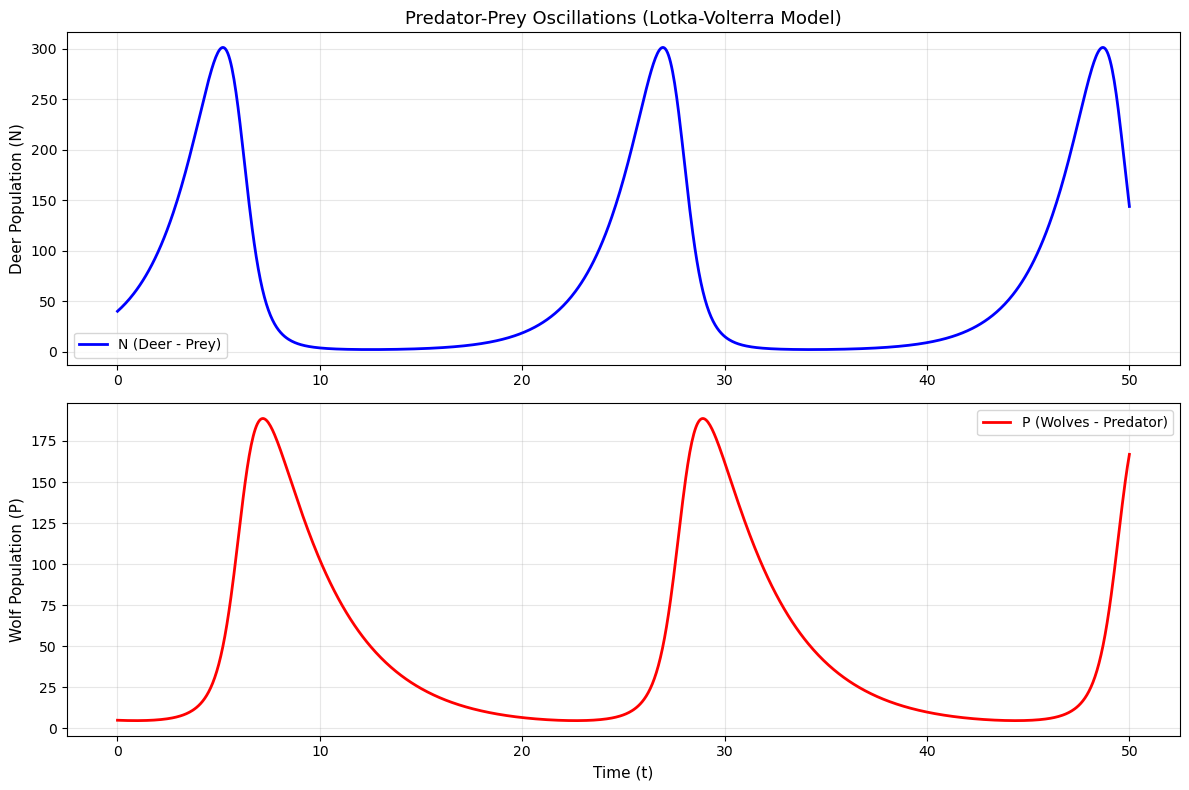

In [58]:
# Lotka-Volterra model: dR/dt = a*R - b*R*W,  dW/dt = c*R*W - d*W
# R = deer (prey), W = wolves (predator)

def lokata (state, t, a, b, c, d):
    """
    Lotka-Volterra predator-prey equations
    dR/dt = a*R - b*R*W  (prey growth minus predation)
    dW/dt = c*R*W - d*W  (predator birth from prey minus death)
    """
    R, W = state
    dRdt = a * R - b * R * W
    dWdt = c * R * W - d * W
    return [dRdt, dWdt]

# Parameters
a = 0.5    # Prey growth rate
b = 0.01   # Predation rate
c = 0.005  # Predation efficiency
d = 0.3    # Predator death rate

# Initial conditions
R0 = 40   # Initial deer population
W0 = 5    # Initial wolf population

# Solve ODE
t_max = 50
t_lv = np.linspace(0, t_max, 1000)
solution = odeint(lokata, [R0, W0], t_lv, args=(a, b, c, d))
R_pop = solution[:, 0]
W_pop = solution[:, 1]

# Plot 1: Time series showing oscillations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(t_lv, R_pop, 'b-', linewidth=2, label='N (Deer - Prey)')
ax1.set_ylabel('Deer Population (N)', fontsize=11)
ax1.set_title('Predator-Prey Oscillations (Lotka-Volterra Model)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(t_lv, W_pop, 'r-', linewidth=2, label='P (Wolves - Predator)')
ax2.set_xlabel('Time (t)', fontsize=11)
ax2.set_ylabel('Wolf Population (P)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The phase portrait shows populations cycling forever in closed loops, while the time series just shows oscillations without revealing they never settle down.

# Gemini Models 
Ivlev function response model

rosenzweig_macarthur model



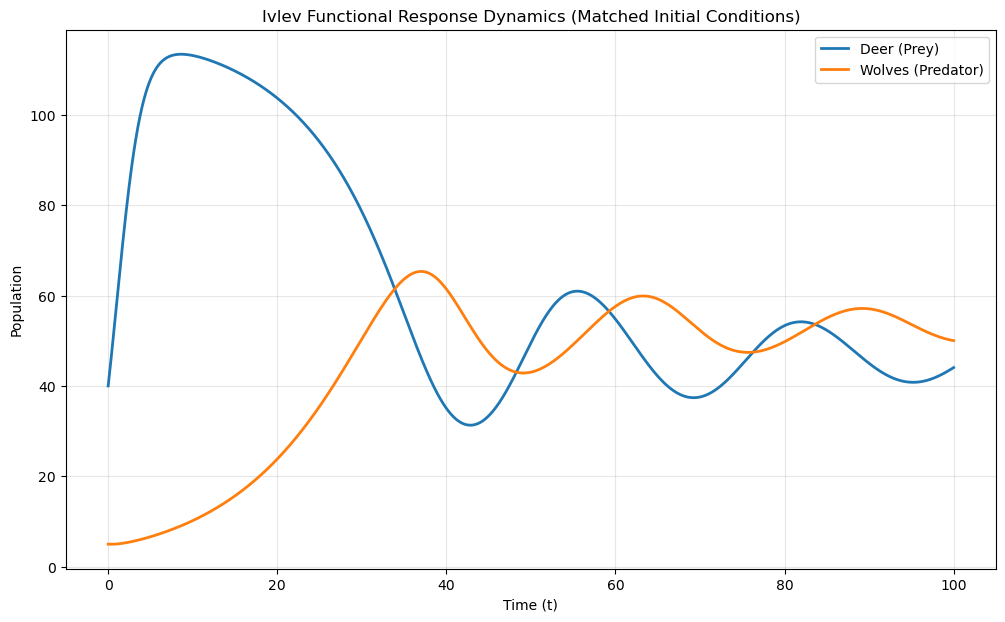

In [59]:
def ivlev(state, t, r, K, c, alpha, beta, m):
    """
    Ivlev functional response predator-prey model
    dx/dt = r*x*(1 - x/K) - c*y*(1 - exp(-alpha*x))
    dy/dt = beta*y*(1 - exp(-alpha*x)) - m*y
    """
    x, y = state
    functional_response = 1 - np.exp(-alpha * x)
    dxdt = r * x * (1 - x / K) - c * y * functional_response
    dydt = beta * y * functional_response - m * y
    return [dxdt, dydt]

# Ivlev parameters (matched to same initial populations) from Gemini
r_iv = 0.7      # moderate prey growth
K_iv = 120      # resource-limited ceiling
c_iv = 0.5      # moderate predation pressure
alpha_iv = 0.03 # gradual saturation response
beta_iv = 0.4   # realistic predator gain
m_iv = 0.3      # baseline predator mortality

R0_iv = R0
W0_iv = W0
t_iv = np.linspace(0, 100, 2000)
sol_iv = odeint(ivlev, [R0_iv, W0_iv], t_iv, args=(r_iv, K_iv, c_iv, alpha_iv, beta_iv, m_iv))
R_iv = sol_iv[:, 0]
W_iv = sol_iv[:, 1]

plt.figure(figsize=(12, 7))
plt.plot(t_iv, R_iv, label='Deer (Prey)', linewidth=2)
plt.plot(t_iv, W_iv, label='Wolves (Predator)', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('Population')
plt.title('Ivlev Functional Response Dynamics (Matched Initial Conditions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

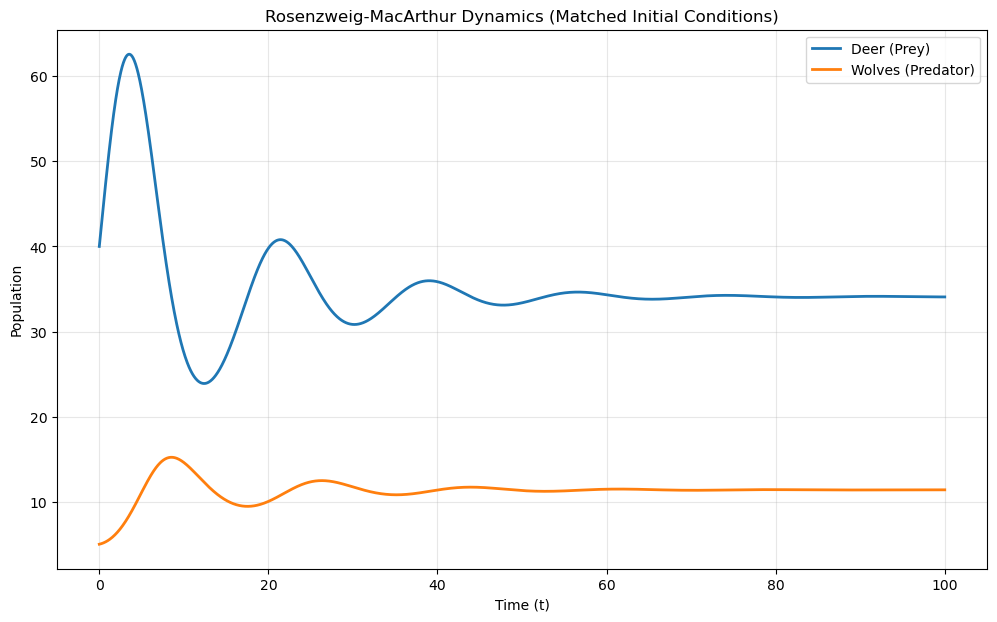

In [60]:
# Gemini model: Rosenzweig-MacArthur Model

def rosenzweig_macarthur(state, t, r, K, a, h, e, m):
    """
    Rosenzweig-MacArthur predator-prey model
    dR/dt = r*R*(1 - R/K) - (a*R*W) / (1 + a*h*R)
    dW/dt = e*(a*R*W) / (1 + a*h*R) - m*W
    """
    R, W = state
    dRdt = r * R * (1 - R / K) - (a * R * W) / (1 + a * h * R)
    dWdt = e * (a * R * W) / (1 + a * h * R) - m * W
    return [dRdt, dWdt]

# Rosenzweig-MacArthur parameters (kept separate from LV params)
r_rm = 0.7    # intrinsic prey growth rate, from gemini: This intrinsic growth rate is set slightly higher than your LV baseline ($0.5$) to compensate for the "braking" effect that carrying capacity and handling time exert on the deer population.
K_rm = 120    # prey carrying capacity :This value was chosen to be significantly higher than the initial deer population ($40$) to provide enough "resource space" for the enrichment that triggers long-term population oscillations.
a_rm = 0.05   # attack rate:This attack rate represents a moderate searching efficiency, ensuring wolves can find enough deer to survive without immediately hunting them to extinction.
h_rm = 0.08   # handling time:This handling time creates a physical limit on consumption, preventing the "infinite killing" seen in LV and allowing the deer population a chance to recover when their numbers are high.
e_rm = 0.2    # conversion efficiency:This efficiency reflects a realistic biological conversion where it takes roughly five deer to successfully produce and raise one new wolf.
m_rm = 0.3    # predator mortality rate:This mortality rate matches your original LV predator death rate ($d=0.3$), keeping the wolf's natural lifespan consistent across both mathematical models.

# Match Lotka-Volterra initial populations
R0_rm = R0
W0_rm = W0
# These initial conditions are standardized to your baseline to demonstrate how the same starting population can lead to a stable "settled" cycle in MacArthur versus a fragile, "memory-dependent" orbit in Lotka-Volterra.
# Simulate
t_rm = np.linspace(0, 100, 2000)
sol_rm = odeint(
    rosenzweig_macarthur,
    [R0_rm, W0_rm],
    t_rm,
    args=(r_rm, K_rm, a_rm, h_rm, e_rm, m_rm)
)
R_rm = sol_rm[:, 0]
W_rm = sol_rm[:, 1]

# Plot time series
plt.figure(figsize=(12, 7))
plt.plot(t_rm, R_rm, label='Deer (Prey)', linewidth=2)
plt.plot(t_rm, W_rm, label='Wolves (Predator)', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('Population')
plt.title('Rosenzweig-MacArthur Dynamics (Matched Initial Conditions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The phase portrait shows spiraling inward to a stable repeating cycle, making it clear that the populations settle into predictable rhythms no matter where you start.

The phase portrait reveals that populations converge toward a fixed point instead of cycling endlessly, showing how ratio-dependent predation fundamentally changes the long-term behavior.

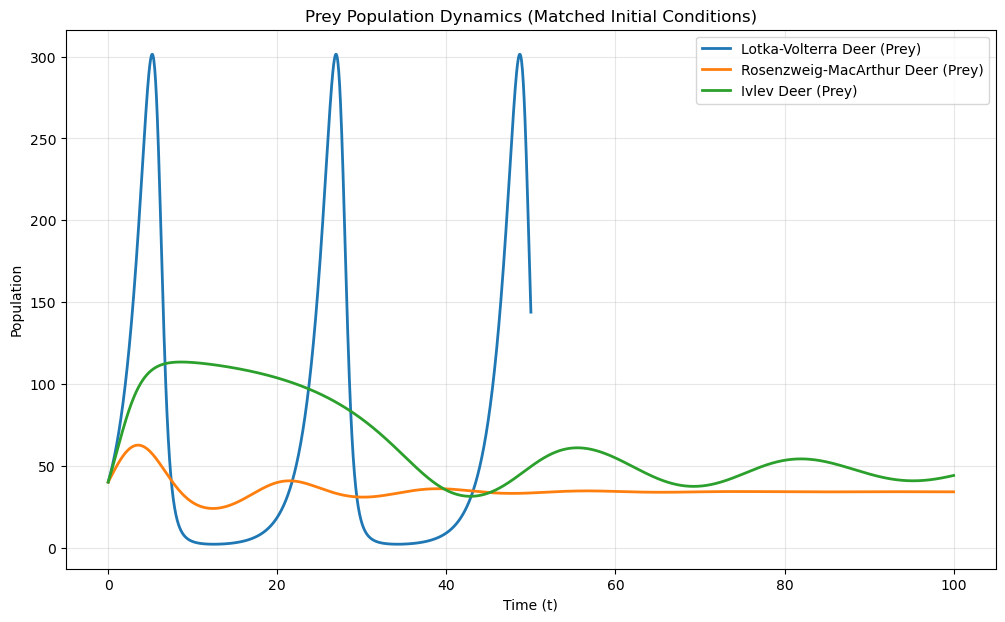

In [61]:
#plottting at 3 models on one graph
plt.figure(figsize=(12, 7))
plt.plot(t_lv, R_pop, label='Lotka-Volterra Deer (Prey)', linewidth=2)
plt.plot(t_rm, R_rm, label='Rosenzweig-MacArthur Deer (Prey)', linewidth=2)
plt.plot(t_iv, R_iv, label='Ivlev Deer (Prey)', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('Population')
plt.title('Prey Population Dynamics (Matched Initial Conditions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

LV coexistence equilibrium: N* = 60.000, P* = 50.000
RM coexistence equilibrium: N* = 34.091, P* = 11.389
Ivlev coexistence equilibrium: N* = 46.210, P* = 53.042


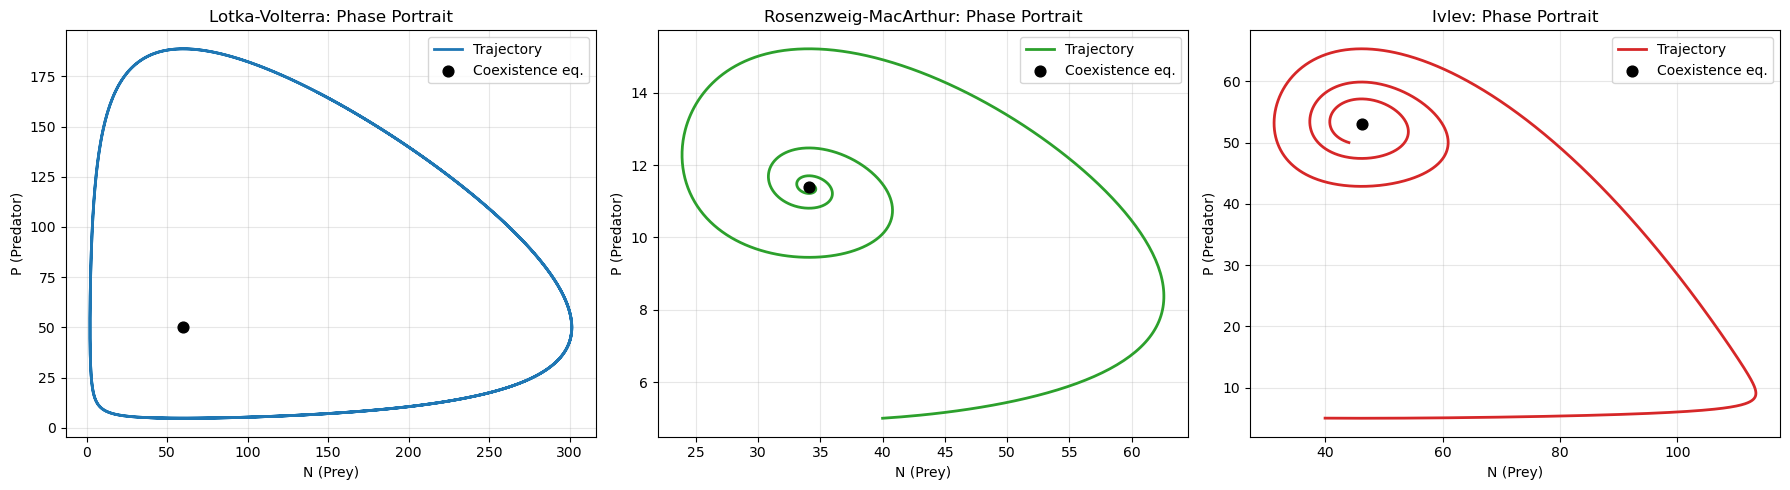

In [62]:
from scipy.optimize import fsolve

# Coexistence equilibria (N*, P*) found numerically for each model
def find_coexistence_equilibrium(rhs_func, guess, args):
    """Solve dN/dt = 0 and dP/dt = 0 near a positive initial guess."""
    def steady_state(vars_):
        N, P = vars_
        dNdt, dPdt = rhs_func([N, P], 0, *args)
        return [dNdt, dPdt]

    sol = fsolve(steady_state, x0=guess)
    return sol[0], sol[1]

# Numerical equilibria
N_star_lv, P_star_lv = find_coexistence_equilibrium(
    lokata, guess=[50, 40], args=(a, b, c, d)
)

N_star_rm, P_star_rm = find_coexistence_equilibrium(
    rosenzweig_macarthur, guess=[35, 12], args=(r_rm, K_rm, a_rm, h_rm, e_rm, m_rm)
)

N_star_iv, P_star_iv = find_coexistence_equilibrium(
    ivlev, guess=[46, 53], args=(r_iv, K_iv, c_iv, alpha_iv, beta_iv, m_iv)
)
print(f"LV coexistence equilibrium: N* = {N_star_lv:.3f}, P* = {P_star_lv:.3f}")
print(f"RM coexistence equilibrium: N* = {N_star_rm:.3f}, P* = {P_star_rm:.3f}")
print(f"Ivlev coexistence equilibrium: N* = {N_star_iv:.3f}, P* = {P_star_iv:.3f}")
# Phase portraits with equilibrium markers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lotka-Volterra
axes[0].plot(R_pop, W_pop, color='tab:blue', linewidth=2, label='Trajectory')
axes[0].scatter(N_star_lv, P_star_lv, color='black', s=60, zorder=3, label='Coexistence eq.')
axes[0].set_title('Lotka-Volterra: Phase Portrait')
axes[0].set_xlabel('N (Prey)')
axes[0].set_ylabel('P (Predator)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Rosenzweig-MacArthur
axes[1].plot(R_rm, W_rm, color='tab:green', linewidth=2, label='Trajectory')
axes[1].scatter(N_star_rm, P_star_rm, color='black', s=60, zorder=3, label='Coexistence eq.')
axes[1].set_title('Rosenzweig-MacArthur: Phase Portrait')
axes[1].set_xlabel('N (Prey)')
axes[1].set_ylabel('P (Predator)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Ivlev
axes[2].plot(R_iv, W_iv, color='tab:red', linewidth=2, label='Trajectory')
axes[2].scatter(N_star_iv, P_star_iv, color='black', s=60, zorder=3, label='Coexistence eq.')
axes[2].set_title('Ivlev: Phase Portrait')
axes[2].set_xlabel('N (Prey)')
axes[2].set_ylabel('P (Predator)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()